In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from tabulate import tabulate
from SQUIC_functions import *
from scipy import sparse

In [2]:
chunk_trns = pd.read_csv(f'rawLog.csv', chunksize=100000)

transactions = pd.concat(chunk_trns)

In [3]:
import pandas as pd
from collections import defaultdict

# Initialize
balances = defaultdict(dict)   # {account: {step: balance}}
fraud_account = set()
users_set = set()

for row in transactions.itertuples(index=False):
    step = row.step
    origin = row.nameOrig
    dest = row.nameDest
    new_orig_balance = row.newBalanceOrig
    new_dest_balance = row.newBalanceDest
    is_fraud = row.isFraud

    # Track users
    users_set.add(origin)
    users_set.add(dest)

    # Track frauds
    if is_fraud == 1:
        fraud_account.add(origin)
        fraud_account.add(dest)

    balances[origin][step] = new_orig_balance
    balances[dest][step] = new_dest_balance

# Finalize user list and properties
users_list = list(users_set)

account_prop = {
    i: {
        "original_id": user,
        "fraud": user in fraud_account,
        "class": str(user)[0]  # 'C', 'M', or 'B'
    }
    for i, user in enumerate(users_list)
}

In [4]:
# Create DataFrame
df = pd.DataFrame.from_dict(balances, orient='index').T

del balances

# Identify the full range of steps (days)
full_range = range(df.index.min(), df.index.max() + 1)

# Reindex to include all steps, then forward fill
df = df.sort_index().reindex(full_range).ffill().bfill()

In [5]:
df

,C1338812845,CC6184384921,M0841523677,C6007389793,CC0844900933,M2489712136,C2309471849,CC3001172410,M5770325089,C9072220360,...,CC5031920882,CC5051180053,CC3032537267,CC3325953605,CC5435978097,CC0171520314,CC4309952572,CC1653607290,CC1832538089,CC5177478159
0,0.0,0.0,53.00,0.00,0.00,60.30,0.00,0.00,39250.82,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,53.00,0.00,0.00,60.30,0.00,0.00,-40137.89,167440.37,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,53.00,0.00,0.00,60.30,0.00,0.00,-40137.89,167440.37,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,53.00,0.00,0.00,60.30,0.00,0.00,-40137.89,167440.37,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,53.00,0.00,0.00,60.30,0.00,0.00,-40137.89,167440.37,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,3908258.0,5207423.6,-17478087.35,2769452.56,5668990.51,-11756402.49,3339375.83,1678570.91,-15967754.27,2401900.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
361,3908258.0,5207423.6,-17478087.35,2769452.56,5668990.51,-11756402.49,3339375.83,1678570.91,-15967754.27,2401900.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
362,3908258.0,5207423.6,-17478087.35,2769452.56,5668990.51,-11756402.49,3339375.83,1678570.91,-15967754.27,2401900.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
363,3908258.0,5207423.6,-17478087.35,2769452.56,5668990.51,-11756402.49,3339375.83,1678570.91,-15967754.27,2401900.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


: 

In [ ]:
max_account_id = max(account_prop) + 1
print(max_account_id)

matrix = lil_matrix((max_account_id, max_account_id), dtype=int)

user_to_id = {user: i for i, user in enumerate(users_list)}

from scipy.sparse import coo_matrix

# Create a dict in which store the amounts (faster than a matrix)
edge_weights = defaultdict(float)

for row in transactions.itertuples(index=False):
    origin = row.nameOrig
    dest = row.nameDest
    amount = row.amount

    if origin in user_to_id and dest in user_to_id:
        i = user_to_id[origin]
        j = user_to_id[dest]
        edge_weights[(i, j)] += amount # update dict

# Convert dict to matrix
rows, cols, data = zip(*[(i, j, amt) for (i, j), amt in edge_weights.items()])
matrix = coo_matrix((data, (rows, cols)), shape=(max_account_id, max_account_id)).tolil()

1021801


In [7]:
matrix

<List of Lists sparse matrix of dtype 'int64'
	with 106939482 stored elements and shape (1021801, 1021801)>

In [ ]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in df.columns:
    if user.startswith('C'):
        color = 'mediumseagreen'
    elif user.startswith('B'):
        color = 'crimson'
    else:
        color = 'darkturquoise'
    plt.plot(df.index, df[user], color=color, label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()

In [9]:
Y = df.T.to_numpy()

In [10]:
# Compute std dev per row
row_std = np.std(Y, axis=1, keepdims=True)

# Avoid division by zero
row_std[row_std == 0] = 1.0

# Normalize each row
Y_new = Y / row_std

In [11]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 2343662836228205.5
Min: -4.5374440182604285
Mean std per row (should be 1): 0.99


In [23]:
l = [0.99999, 0.9999, 0.999, 0.995, 0.992, 0.99]

In [24]:
Theta_dict = {}

In [25]:
ROWS = Y_new.shape[0]
ROWS

102249

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           102249 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.990000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=9.76e+00 nnz(S)/p=1.34e+00
* iter=1 time=1.70e-01 obj=2.03e+05 |delta(obj)|/obj=5.00e-01 nnz(X,L,W)/p=[1.34e+00 6.75e-01 1.00e+00] lns_iter=8 
* iter=2 time=2.63e-01 obj=2.00e+05 |delta(obj)|/obj=1.52e-02 nnz(X,L,W)/p=[1.34e+00 6.75e-01 1.00e+00] lns_iter=6 
* iter=3 time=3.63e-01 obj=1.90e+05 |delta(obj)|

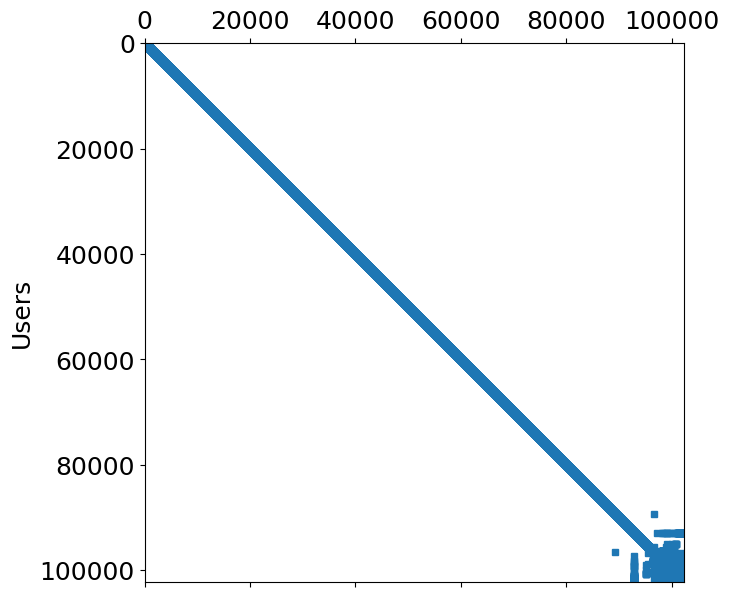

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           102249 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.950000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=9.61e+00 nnz(S)/p=1.55e+00
* iter=1 time=1.63e-01 obj=2.02e+05 |delta(obj)|/obj=4.99e-01 nnz(X,L,W)/p=[1.55e+00 9.44e-01 1.00e+00] lns_iter=8 
* iter=2 time=2.76e-01 obj=1.99e+05 |delta(obj)|/obj=1.51e-02 nnz(X,L,W)/p=[1.55e+00 9.44e-01 1.00e+00] lns_iter=6 
* iter=3 time=3.74e-01 obj=1.89e+05 |delta(obj)|

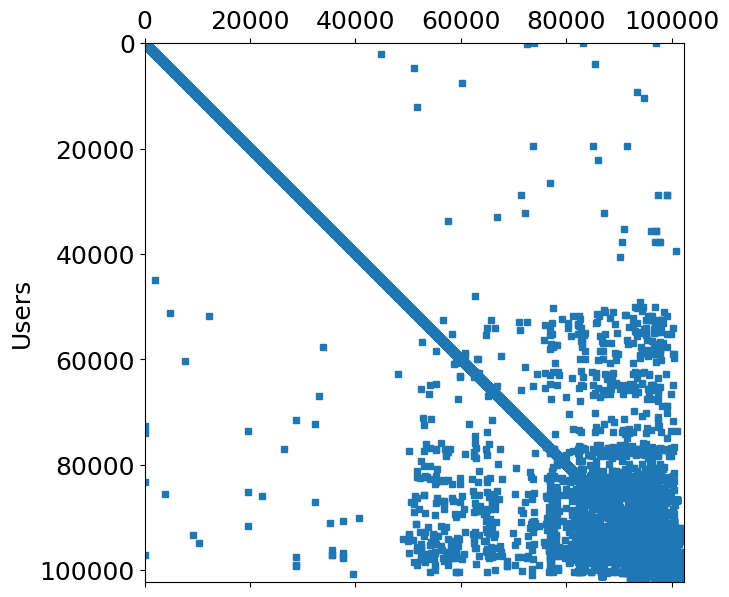

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           102249 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.920000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.00e+01 nnz(S)/p=2.22e+00
* iter=1 time=2.25e-01 obj=2.02e+05 |delta(obj)|/obj=4.98e-01 nnz(X,L,W)/p=[2.22e+00 7.91e+00 1.00e+00] lns_iter=8 
* iter=2 time=3.54e-01 obj=1.99e+05 |delta(obj)|/obj=1.50e-02 nnz(X,L,W)/p=[2.22e+00 7.91e+00 1.00e+00] lns_iter=6 
* iter=3 time=5.96e-01 obj=1.89e+05 |delta(obj)|

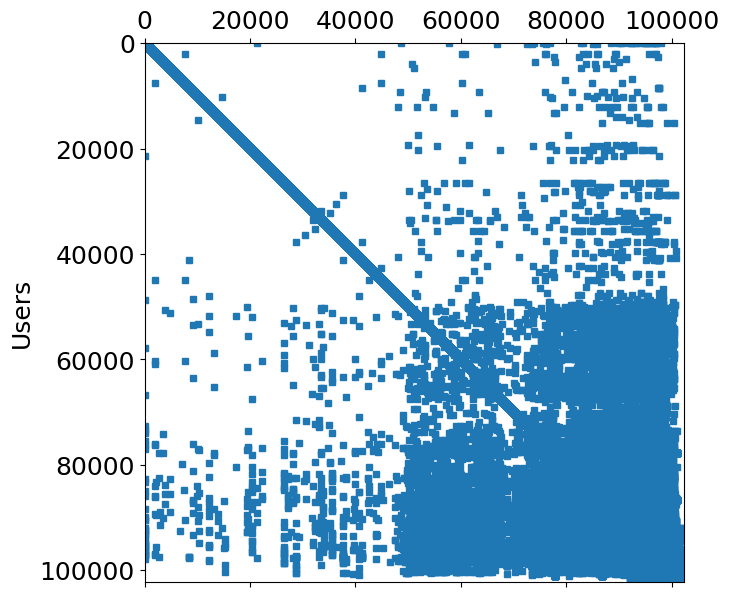

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           102249 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.900000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=9.98e+00 nnz(S)/p=3.35e+00
* iter=1 time=4.20e-01 obj=2.02e+05 |delta(obj)|/obj=4.97e-01 nnz(X,L,W)/p=[3.35e+00 3.58e+01 1.00e+00] lns_iter=8 
* iter=2 time=5.99e-01 obj=1.99e+05 |delta(obj)|/obj=1.49e-02 nnz(X,L,W)/p=[3.35e+00 3.58e+01 1.00e+00] lns_iter=6 
* iter=3 time=1.13e+00 obj=1.89e+05 |delta(obj)|

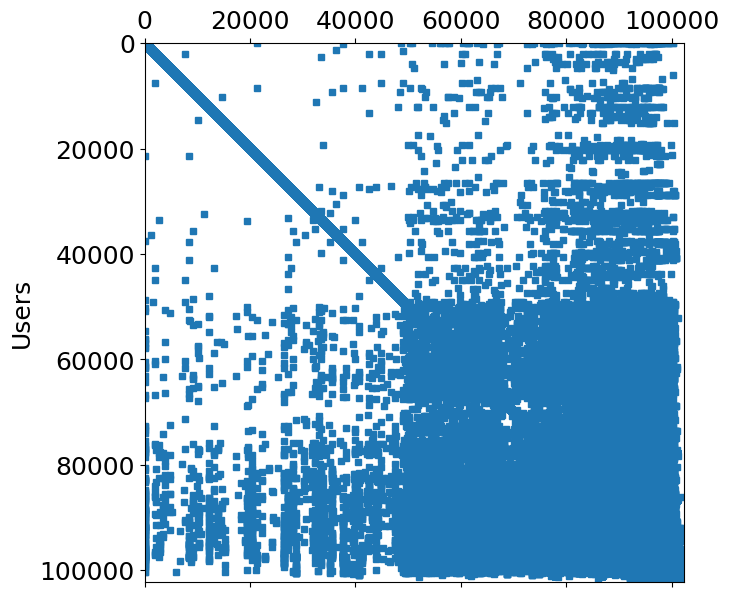

In [26]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    Theta, _, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    print(f"time required: {computation_time} seconds")

    Theta = sparse.csr_matrix(Theta) # store Theta as sparse
    Theta_dict[rho] = Theta

    nonz, nonz_r = nnz_sparse(Theta_dict[rho], ROWS)

    print("Checking if symmetric")
    if check_symmetric_sparse(Theta_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(Theta_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(Theta_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(Theta_dict[rho])


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# SQUIC-Fit


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.035831e+02
 Y:         102249 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.990000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.34e+00 time=1.04e+01
* iter=1 time=5.19e-01 obj=2.03e+05 |delta(obj)|/obj=5.00e-01 nnz(X,L,W)/p=[1.34e+00 6.75e-01 1.00e+00] lns_iter=8 
* iter=2 time=5.79e-01 obj=2.00e+05 |delta(obj)|/obj=1.52e-02 nnz(X,L,W)/p=[1.34e+00 6.75e-01 1.00e+00] lns_iter=6 
* iter=3 time=6.51e-01 obj=1.90e+05 

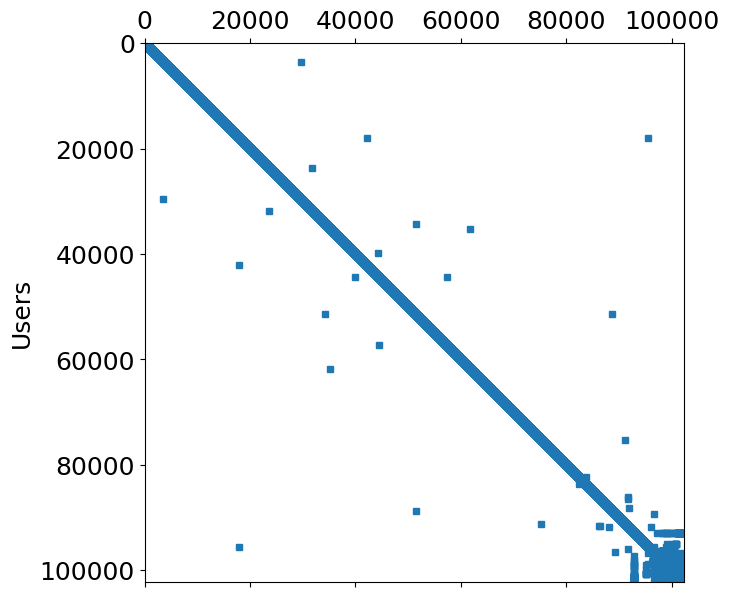

✅ Matrix is symmetric per rho 0.999

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.035831e+02
 Y:         102249 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.950000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.55e+00 time=1.04e+01
* iter=1 time=5.46e-01 obj=2.02e+05 |delta(obj)|/obj=4.99e-01 nnz(X,L,W)/p=[1.55e+00 9.39e-01 1.00e+00] lns_iter=8 
* iter=2 time=6.16e-01 obj=1.99e+05 |delta(obj)|/obj=1.51e-02 nnz(X,L,W)/p=[1.55e+00 9.39e-01 1.00e+00] lns_iter=6 


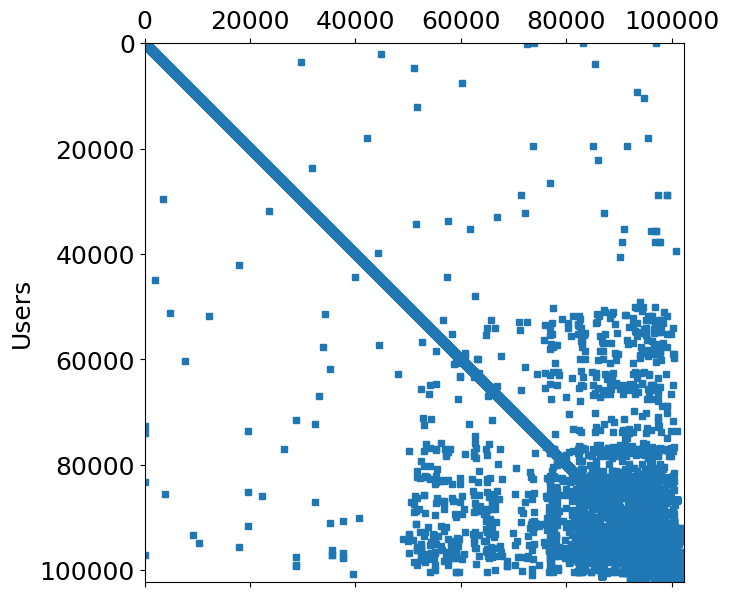

✅ Matrix is symmetric per rho 0.995

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.035831e+02
 Y:         102249 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.920000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.22e+00 time=1.03e+01
* iter=1 time=6.15e-01 obj=2.02e+05 |delta(obj)|/obj=4.98e-01 nnz(X,L,W)/p=[2.22e+00 8.02e+00 1.00e+00] lns_iter=8 
* iter=2 time=6.68e-01 obj=1.99e+05 |delta(obj)|/obj=1.50e-02 nnz(X,L,W)/p=[2.22e+00 8.02e+00 1.00e+00] lns_iter=6 


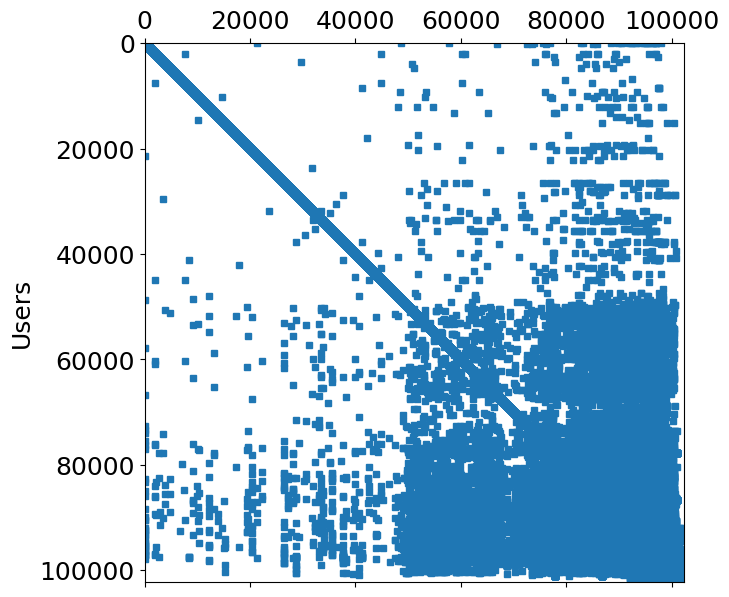

✅ Matrix is symmetric per rho 0.992

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    2.035831e+02
 Y:         102249 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.900000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=3.35e+00 time=1.04e+01
* iter=1 time=8.55e-01 obj=2.02e+05 |delta(obj)|/obj=4.97e-01 nnz(X,L,W)/p=[3.35e+00 3.81e+01 1.00e+00] lns_iter=8 
* iter=2 time=9.61e-01 obj=1.99e+05 |delta(obj)|/obj=1.49e-02 nnz(X,L,W)/p=[3.35e+00 3.81e+01 1.00e+00] lns_iter=6 


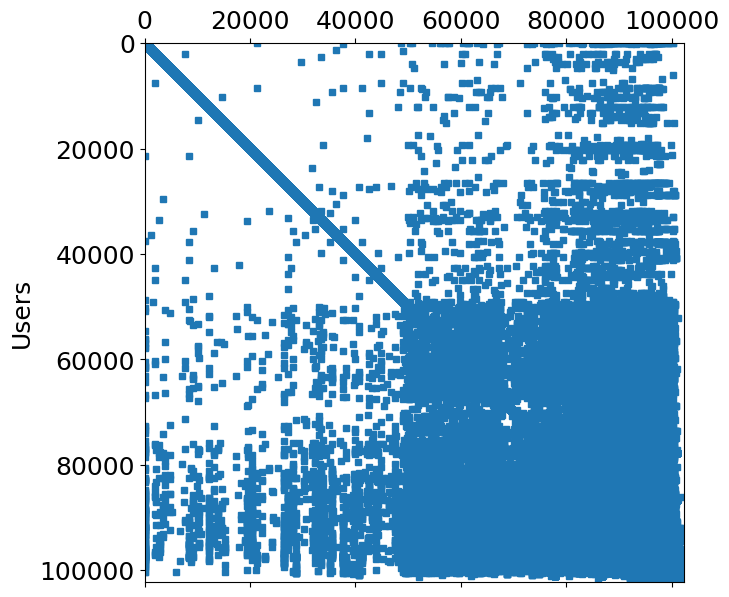

✅ Matrix is symmetric per rho 0.99


In [27]:
W_dict = {}

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    W, end_time = squic_fit_matrix_sparse(Y_new, l=rho, matrix=matrix)
    W_dict[rho] = sparse.csr_matrix(W)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_sparse(W_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(W_dict[rho])

    if check_symmetric_sparse(W_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append("No")

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]


In [28]:
from tabulate import tabulate

In [29]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [30]:
print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit_norm, "SQUIC FIT NORM", l))

╒══════════════╤═════════╤═════════╤═════════╤════════╕
│  SQUIC NORM  │  0.999  │  0.995  │  0.992  │  0.99  │
╞══════════════╪═════════╪═════════╪═════════╪════════╡
│     NNZ      │ 136787  │ 158845  │ 224983  │ 342389 │
├──────────────┼─────────┼─────────┼─────────┼────────┤
│   NNZ/Row    │  1.34   │  1.55   │   2.2   │  3.35  │
├──────────────┼─────────┼─────────┼─────────┼────────┤
│   Time (s)   │  11.28  │  11.66  │  12.6   │ 16.63  │
├──────────────┼─────────┼─────────┼─────────┼────────┤
│  Symmetric   │   Yes   │   Yes   │   Yes   │  Yes   │
╘══════════════╧═════════╧═════════╧═════════╧════════╛
╒══════════════════╤═════════╤═════════╤═════════╤════════╕
│  SQUIC FIT NORM  │  0.999  │  0.995  │  0.992  │  0.99  │
╞══════════════════╪═════════╪═════════╪═════════╪════════╡
│       NNZ        │ 136761  │ 158787  │ 226503  │ 341983 │
├──────────────────┼─────────┼─────────┼─────────┼────────┤
│     NNZ/Row      │  1.34   │  1.55   │  2.22   │  3.34  │
├──────────────────┼────

In [31]:
def labels_to_partition(labels):
    """Convert label array [0,0,1,1,2,2] -> list of sets [{0,1},{2,3},{4,5}]"""
    clusters = {}
    for idx, label in enumerate(labels):
        if label not in clusters:
            clusters[label] = set()
        clusters[label].add(idx)

    # Remove noise points if using DBSCAN (-1 labels)
    if -1 in clusters:
        noise_nodes = clusters.pop(-1)
        for node in noise_nodes:
            clusters[f'noise_{node}'] = {node}  # unique labels for noise

    return list(clusters.values())

In [32]:
# import networkx as nx
# from networkx.algorithms import community
# from sklearn.cluster import DBSCAN, SpectralClustering
# from sklearn.manifold import SpectralEmbedding
# from tqdm.auto import tqdm  # Correct import for progress bars

# def clustering(W_matrices):
#     dict_cluster = {
#         "louvain" : {},
#         "spectral" : {},
#         "dbscan" : {}
#     }

#     for rho, W in W_matrices.items():
#         # Ensure all off-diagonal entries are positive and diagonal is zero
#         W.data = np.abs(W.data)
#         W.setdiag(0)
#         W.eliminate_zeros()  # Remove explicit zeros

#         # Create a graph from matrix W
#         G = nx.from_scipy_sparse_array(W)

#         embedding = SpectralEmbedding(n_components=10, affinity='precomputed')
#         X = embedding.fit_transform(W)      

#         # Louvain
#         partition = community.louvain_communities(G)
#         print(f"n cluster louvain : {len(partition)}")
#         dict_cluster['louvain'][rho] = partition

#         n_cluster_louvain =  len(partition)


#         # DBSCAN with multiple params
#         best_score = float('inf')
#         best_params = None

#         eps_range = np.linspace(0.1, 2.0, 20)
#         min_samples_range = range(3, 10)

#         for eps in tqdm(eps_range):
#             for min_samples in min_samples_range:
#                 dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#                 labels = dbscan.fit_predict(X)
                
#                 # Ignore if all points are noise (-1) or single cluster
#                 if len(set(labels)) <= 1 or (set(labels) == {-1}):
#                     continue

#                 partition = labels_to_partition(labels)

#                 diff = abs(len(partition) - n_cluster_louvain)
#                 if diff < best_score:
#                     best_score = diff
#                     best_params = (eps, min_samples)

#         if best_params is not None:
#             print(f"Best params: eps={best_params[0]}, min_samples={best_params[1]}")
#             print(f"Best difference in number of clusters: {best_score:.4f}")
#             dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
#         else:
#             print("No suitable DBSCAN parameters found!")
#             dbscan = DBSCAN()

#         labels_dbscan = dbscan.fit_predict(X)
#         print(f"n cluster dbscan = {len(labels_dbscan)}")

#         # Convert labels to list of sets
#         partition_dbscan = labels_to_partition(labels_dbscan)
#         dict_cluster['dbscan'][rho] = partition_dbscan


#         # Use n_cluster = len(partitionin louvain)
#         clustering = SpectralClustering(n_clusters=n_cluster_louvain, affinity='precomputed', assign_labels='cluster_qr')
#         labels_spectral = clustering.fit_predict(X)

#         # Convert labels to list of sets
#         partition_spectral = labels_to_partition(labels_spectral)
#         print(f"n cluster spectral = {len(labels_spectral)}\n")

#         dict_cluster['spectral'][rho] = partition_spectral
    
#     return dict_cluster

In [33]:
#  dict_cluster = clustering(W_dict)